<a href="https://colab.research.google.com/github/graciasheren6-rgb/caliber-2026-case2/blob/main/CALIBER_Case2_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CALIBER 2026 · Case 2 — Analysis summary
- Incident DB: 380 incidents, 2,261.1 h downtime, US$67,194K total loss (ROT: 145 incidents, 900 h, US$26,834K)
- Early warning replay on 5 RCA cases: first ALARM to TRIP = 6, 6, 10, 11, 15 weeks (mean 9.6)
- Production sensors: early warning per equipment is printed in the last section ("Early-warning summary")
- PM compliance: 92% for all 5 equipment (uniform, not a differentiator)

*Cara pakai: Runtime > Restart and run all. Sel pertama akan minta izin Google Drive.*

## Case 2 Bagian Equipment

In [1]:
# CELL 1 — import library
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100

Mounted at /content/drive


In [2]:
# CELL 2 — baca file dari folder & langsung salin ke local disk
# (biar parsing gak kena 'Transport endpoint is not connected' akibat Drive FUSE disconnect)
import glob, os, shutil

folder = "/content/drive/MyDrive/Supporting Data/Case 2: Intelligence Manufacturing/Equipment Performance"
print("Folder ketemu di:", folder)
file_list = sorted(glob.glob(f"{folder}/*.xlsx"))

local_dir_eq = "/content/eqperf_local"
os.makedirs(local_dir_eq, exist_ok=True)
file_list = [shutil.copy(f, os.path.join(local_dir_eq, os.path.basename(f))) for f in file_list]
print("File yang kebaca (sudah disalin ke local):", file_list)

Folder ketemu di: /content/drive/MyDrive/Supporting Data/Case 2: Intelligence Manufacturing/Equipment Performance
File yang kebaca (sudah disalin ke local): ['/content/eqperf_local/Equipment Performance - RCA1 PU-2101B.xlsx', '/content/eqperf_local/Equipment Performance - RCA2 KO-3201.xlsx', '/content/eqperf_local/Equipment Performance - RCA3 PM-4405B.xlsx', '/content/eqperf_local/Equipment Performance - RCA4 HE-3301.xlsx', '/content/eqperf_local/Equipment Performance - RCA5 BL-5702.xlsx']


In [3]:
# CELL 3 — fungsi parsing (versi robust, scan semua baris) + Week/Days_to_Failure
limits_raw_by_tag = {}   # baris batas alarm/trip mentah (dipakai untuk garis di grafik)

def parse_file(f):
    wb = openpyxl.load_workbook(f, data_only=True)

    ws = wb['Equipment Info']
    info, limits, limits_raw = {}, {}, {}
    for r in ws.iter_rows(values_only=True):
        if r[0] and r[1] is not None:
            info[str(r[0]).strip()] = r[1]
        if len(r) > 3 and r[2] is not None and str(r[2]).strip() != 'Parameter':
            limits[str(r[2]).strip()] = r[3]
            limits_raw[str(r[2]).strip()] = list(r[3:])
    tag = info.get('Equipment Tag', f)
    limits_raw_by_tag[tag] = limits_raw

    ws2 = wb['Condition History']
    df = pd.DataFrame(ws2.iter_rows(values_only=True))
    df.columns = [str(c).replace('\n', ' ') for c in df.iloc[0]]
    df = df[1:].reset_index(drop=True)
    df['Date'] = pd.to_datetime(df['Date'])
    df['Week'] = pd.to_numeric(df['Week'])
    param_cols = [c for c in df.columns if c not in ('Week', 'Date', 'Health Status', 'Remark')]
    for c in param_cols:
        df[c] = pd.to_numeric(df[c])
    df['Equipment Tag'] = tag
    df['Equipment Name'] = info.get('Equipment Name')

    # --- Week_to_Failure & Days_to_Failure: sumbu waktu relatif ke minggu TRIP ---
    trip_week = df.loc[df['Health Status'] == 'TRIP', 'Week']
    ref_week = trip_week.iloc[0] if not trip_week.empty else df['Week'].max()
    df['Week_to_Failure'] = df['Week'] - ref_week
    df['Days_to_Failure'] = df['Week_to_Failure'] * 7

    ws3 = wb['Performance Summary']
    kpi = {}
    for r in ws3.iter_rows(values_only=True):
        if r[0] and r[1] is not None and r[0] != 'KPI' and 'PERFORMANCE SUMMARY' not in str(r[0]):
            kpi[r[0]] = r[1]
    kpi['Equipment Tag'] = tag

    return info, limits, df, kpi, param_cols


all_info, all_kpi = [], []
limits_by_tag, history_by_tag, params_by_tag = {}, {}, {}

for f in file_list:
    info, limits, df, kpi, param_cols = parse_file(f)
    all_info.append(info)
    all_kpi.append(kpi)
    limits_by_tag[info['Equipment Tag']] = limits
    history_by_tag[info['Equipment Tag']] = df
    params_by_tag[info['Equipment Tag']] = param_cols

info_df = pd.DataFrame(all_info)
kpi_df = pd.DataFrame(all_kpi).set_index('Equipment Tag')
history_all = pd.concat(history_by_tag.values(), ignore_index=True)

print("Equipment yang kebaca:", list(history_by_tag.keys()))
print("Kolom info_df:", info_df.columns.tolist())

Equipment yang kebaca: ['PU-2101B', 'KO-3201', 'PM-4405B', 'HE-3301', 'BL-5702']
Kolom info_df: ['Equipment Tag', 'Equipment Name', 'Equipment Type', 'Equipment Class', 'Plant / Unit', 'Discipline', 'Criticality', 'Design Life', 'Monitoring Method', 'Linked RCA / AR No.', 'Failure Date', 'Dominant Failure Mode']


In [4]:
# CELL 4 — ringkasan nameplate
cols = ['Equipment Tag','Equipment Name','Equipment Type','Equipment Class',
        'Plant / Unit','Criticality','Dominant Failure Mode','Failure Date']
info_df.reindex(columns=cols)

,Equipment Tag,Equipment Name,Equipment Type,Equipment Class,Plant / Unit,Criticality,Dominant Failure Mode,Failure Date
0,PU-2101B,Feed Charge Pump PU-2101B,Centrifugal Pump,B,Resin Plant (ARP),Medium,Mechanical Seal Leakage,12-Mar-2026
1,KO-3201,Cracked Gas Compressor KO-3201,Centrifugal Compressor,A,Cracker Unit (ZCU),High,High Radial Vibration Trip (Bearing Distress),29-Apr-2026
2,PM-4405B,Cooling Water Pump PM-4405B (Motor Driven),Centrifugal Pump / Electric Motor,B,Utility Plant (NUP),Medium,Motor Bearing Failure (Overheating),08-Jul-2026
3,HE-3301,Feed/Effluent Heat Exchanger HE-3301,Shell & Tube Heat Exchanger,B,Cracker Unit (ZCU),Medium,High Fouling — Duty Loss & High dP,21-May-2026
4,BL-5702,Product Blower BL-5702,Centrifugal Blower,A,Polymer Plant (OPP),High,High Vibration (Coupling Misalignment),17-Jun-2026


In [5]:
# CELL 5 — KPI table
kpi_df

,Monitoring Period (weeks),Total Downtime (hours),Period Hours,Availability (%),No. of Failures (period),MTBF (hours),MTTR (hours),ALARM readings,TRIP readings,NORMAL readings,PM Compliance (%),Production Loss (ton),Estimated Loss (k USD)
Equipment Tag,,,,,,,,,,,,,
PU-2101B,26,18.5,4368,99.576465,1,4368,18.5,6,1,19,92,251.6,226.44
KO-3201,26,32.0,4368,99.267399,1,4368,32.0,11,1,14,92,1760.0,1584.00
PM-4405B,26,8.0,4368,99.816850,1,4368,8.0,6,1,19,92,160.0,112.00
HE-3301,26,12.0,4368,99.725275,1,4368,12.0,10,1,15,92,216.0,183.60
BL-5702,26,14.0,4368,99.679487,1,4368,14.0,15,1,10,92,532.0,478.80


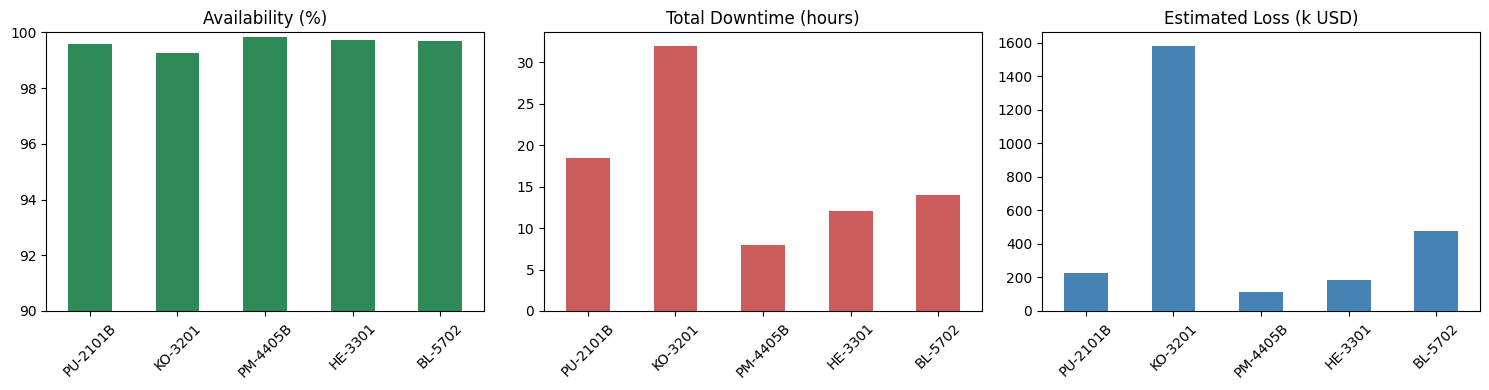

In [6]:
# CELL 5b — KPI chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kpi_df['Availability (%)'].plot(kind='bar', ax=axes[0], color='seagreen', title='Availability (%)')
axes[0].set_ylim(90, 100)
kpi_df['Total Downtime (hours)'].plot(kind='bar', ax=axes[1], color='indianred', title='Total Downtime (hours)')
kpi_df['Estimated Loss (k USD)'].plot(kind='bar', ax=axes[2], color='steelblue', title='Estimated Loss (k USD)')
for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

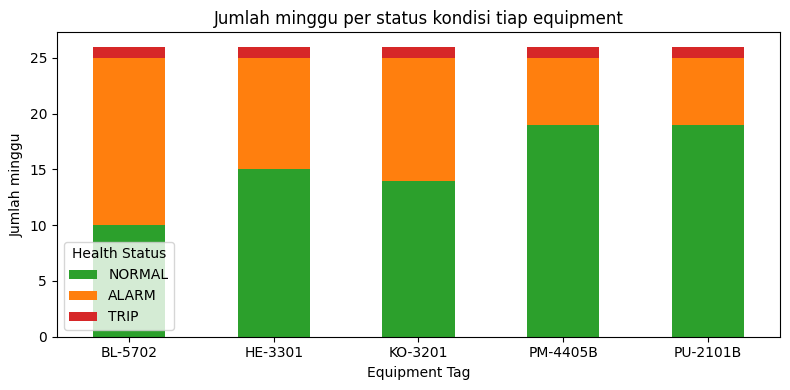

In [7]:
# CELL 6 — distribusi status NORMAL/ALARM/TRIP
status_ct = history_all.groupby(['Equipment Tag', 'Health Status']).size().unstack(fill_value=0)
status_ct = status_ct[[c for c in ['NORMAL','ALARM','TRIP'] if c in status_ct.columns]]

status_ct.plot(kind='bar', stacked=True, figsize=(8,4),
               color={'NORMAL':'tab:green','ALARM':'tab:orange','TRIP':'tab:red'})
plt.title('Jumlah minggu per status kondisi tiap equipment')
plt.ylabel('Jumlah minggu')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
# CELL 7 — tren tiap parameter per equipment (dropdown, satu-satu biar nggak numpuk)
import re
import ipywidgets as widgets

status_colors = {'NORMAL': 'tab:green', 'ALARM': 'tab:orange', 'TRIP': 'tab:red'}

def _norm(s):
    return ' '.join(str(s).split()).lower()

def _limit_numbers(tag, col):
    """Angka batas dari sheet Equipment Info: urutan pertama = alarm, kedua = trip."""
    for k, vals in limits_raw_by_tag.get(tag, {}).items():
        if _norm(k) == _norm(col):
            nums = []
            for v in vals:
                if isinstance(v, (int, float)) and not isinstance(v, bool):
                    nums.append(float(v))
                elif isinstance(v, str):
                    nums += [float(x) for x in re.findall(r'-?\d+(?:\.\d+)?', v.replace(',', ''))]
            return nums[:2]
    return []

def plot_equipment(tag):
    df = history_by_tag[tag]
    info_row = info_df[info_df['Equipment Tag'] == tag].iloc[0]
    param_cols = params_by_tag[tag]
    fail_date = pd.to_datetime(info_row['Failure Date'], format='%d-%b-%Y', errors='coerce')

    fig, axes = plt.subplots(len(param_cols), 1, figsize=(9, 2.8*len(param_cols)), sharex=True)
    if len(param_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, param_cols):
        ax.plot(df['Date'], df[col], color='steelblue', lw=1, zorder=1)
        ax.scatter(df['Date'], df[col], c=[status_colors[s] for s in df['Health Status']], s=18, zorder=3)
        nums = _limit_numbers(tag, col)
        if len(nums) >= 2:
            ax.axhline(nums[0], color='orange', ls='--', lw=1, label=f'Alarm {nums[0]:g}')
            ax.axhline(nums[1], color='red', ls='--', lw=1, label=f'Trip {nums[1]:g}')
            ax.legend(fontsize=7, loc='upper left')
        if pd.notna(fail_date):
            ax.axvline(fail_date, color='black', ls=':', lw=1)
        ax.set_ylabel(col, fontsize=8)

    fig.suptitle(f"{tag} — {info_row['Equipment Name']}  |  {info_row['Dominant Failure Mode']}", fontsize=10)
    plt.tight_layout()
    plt.show()

widgets.interact(plot_equipment,
                 tag=widgets.Dropdown(options=list(history_by_tag.keys()), description='Equipment:'));

interactive(children=(Dropdown(description='Equipment:', options=('PU-2101B', 'KO-3201', 'PM-4405B', 'HE-3301'…

In [9]:
# CELL 8 — Kesimpulan Equipment Performance
print("="*60)
print("KESIMPULAN — EQUIPMENT PERFORMANCE (Inspeksi Mingguan)")
print("="*60)

worst_avail = kpi_df['Availability (%)'].idxmin()
worst_downtime = kpi_df['Total Downtime (hours)'].idxmax()
worst_loss = kpi_df['Estimated Loss (k USD)'].idxmax()

print(f"\n1. Availability terendah : {worst_avail} ({kpi_df.loc[worst_avail,'Availability (%)']:.2f}%)")
print(f"2. Downtime terbesar     : {worst_downtime} ({kpi_df.loc[worst_downtime,'Total Downtime (hours)']:.0f} jam)")
print(f"3. Estimated loss terbesar: {worst_loss} (${kpi_df.loc[worst_loss,'Estimated Loss (k USD)']:.0f}k)")

# KODE B — PM compliance: kalau semua sama, jangan tunjuk satu equipment
pm = kpi_df['PM Compliance (%)']
if pm.nunique() == 1:
    print(f"4. PM Compliance: semua equipment {pm.iloc[0]:.0f}%")
else:
    print(f"4. PM Compliance terendah: {pm.idxmin()} ({pm.min():.0f}%)")

print(f"\n5. Total downtime seluruh equipment : {kpi_df['Total Downtime (hours)'].sum():.0f} jam")
print(f"6. Total estimated loss seluruh equipment: ${kpi_df['Estimated Loss (k USD)'].sum():.0f}k")

status_ct_summary = history_all.groupby('Equipment Tag')['Health Status'].value_counts().unstack(fill_value=0)
print(f"\n7. Distribusi status per equipment (minggu NORMAL/ALARM/TRIP):")
print(status_ct_summary)

KESIMPULAN — EQUIPMENT PERFORMANCE (Inspeksi Mingguan)

1. Availability terendah : KO-3201 (99.27%)
2. Downtime terbesar     : KO-3201 (32 jam)
3. Estimated loss terbesar: KO-3201 ($1584k)
4. PM Compliance: semua equipment 92%

5. Total downtime seluruh equipment : 84 jam
6. Total estimated loss seluruh equipment: $2585k

7. Distribusi status per equipment (minggu NORMAL/ALARM/TRIP):
Health Status  ALARM  NORMAL  TRIP
Equipment Tag                     
BL-5702           15      10     1
HE-3301           10      15     1
KO-3201           11      14     1
PM-4405B           6      19     1
PU-2101B           6      19     1


## Case 2 Production

In [10]:
# CELL 9 — baca file Production Data & langsung salin ke local disk
import glob, os, shutil

prod_folder = "/content/drive/MyDrive/Supporting Data/Case 2: Intelligence Manufacturing/Production Data"
print("Folder ketemu di:", prod_folder)
prod_file_list = sorted(glob.glob(f"{prod_folder}/*.xlsx"))

local_dir_prod = "/content/prod_local"
os.makedirs(local_dir_prod, exist_ok=True)
prod_file_list = [shutil.copy(f, os.path.join(local_dir_prod, os.path.basename(f))) for f in prod_file_list]
print("File yang kebaca (sudah disalin ke local):", prod_file_list)

Folder ketemu di: /content/drive/MyDrive/Supporting Data/Case 2: Intelligence Manufacturing/Production Data
File yang kebaca (sudah disalin ke local): ['/content/prod_local/Production Data - RCA1 PU-2101B.xlsx', '/content/prod_local/Production Data - RCA2 KO-3201.xlsx', '/content/prod_local/Production Data - RCA3 PM-4405B.xlsx', '/content/prod_local/Production Data - RCA4 HE-3301.xlsx', '/content/prod_local/Production Data - RCA5 BL-5702.xlsx']


In [11]:
# CELL 10 — parsing Production Data + Hours/Days_to_Failure
import numpy as np

def parse_prod(f):
    wb = openpyxl.load_workbook(f, data_only=True)

    ws = wb['PI Tag']
    tag_rows = list(ws.iter_rows(values_only=True))[1:]
    tag = tag_rows[0][0].split('_')[0]

    ws2 = wb['Sheet2']
    df = pd.DataFrame(ws2.iter_rows(values_only=True))
    df.columns = df.iloc[0]
    df = df[1:].reset_index(drop=True)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values('Timestamp').reset_index(drop=True)

    rename = {c: c.split(tag + '_', 1)[1] for c in df.columns if str(c).startswith(tag + '_')}
    df = df.rename(columns=rename)

    for c in ['FEED', 'DISP', 'VIB', 'TEMP', 'AMP', 'PLANT_RATE']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c])
    df['Equipment Tag'] = tag

    # --- waktu TRIP FINAL: awal dari BLOK OFF TERAKHIR di seluruh data ---
    # cari OFF PALING TERAKHIR, lalu mundur ke awal blok OFF itu (titik mulai trip).
    off_mask = df['RUN_STATUS'] == 'OFF'
    fail_dt = None
    if off_mask.any():
        last_off_idx = df.index[off_mask][-1]
        start_idx = last_off_idx
        while start_idx > df.index[0] and df.loc[start_idx - 1, 'RUN_STATUS'] == 'OFF':
            start_idx -= 1
        fail_dt = df.loc[start_idx, 'Timestamp']

    # Kolom SELALU dibuat (diisi NaN kalau gak ketemu titik trip-nya) biar kode lain gak KeyError.
    if fail_dt is not None:
        df['Hours_to_Failure'] = (df['Timestamp'] - fail_dt).dt.total_seconds() / 3600
    else:
        df['Hours_to_Failure'] = np.nan
    df['Days_to_Failure'] = df['Hours_to_Failure'] / 24   # satuan sama dgn Equipment Performance

    return tag, df

prod_history = {}
for f in prod_file_list:
    tag, df = parse_prod(f)
    prod_history[tag] = df
    if df['Hours_to_Failure'].isna().all():
        print(f"⚠️  PERINGATAN: {tag} tidak punya baris RUN_STATUS == 'OFF' sama sekali -- "
              f"Hours_to_Failure/Days_to_Failure kosong (NaN) untuk equipment ini. Cek data mentahnya.")

print("Equipment yang kebaca:", list(prod_history.keys()))
prod_history[list(prod_history.keys())[0]].describe()

Equipment yang kebaca: ['PU2101B', 'KO3201', 'PM4405B', 'HE3301', 'BL5702']


,Timestamp,FEED,DISP,VIB,TEMP,AMP,PLANT_RATE,Hours_to_Failure,Days_to_Failure
count,720,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2026-03-15 23:30:00,13.248932,9.229304,3.783721,64.418750,131.564972,13.509739,92.500000,3.854167
min,2026-03-01 00:00:00,0.000000,0.197000,0.173000,35.440000,2.550000,0.000000,-267.000000,-11.125000
25%,2026-03-08 11:45:00,13.396750,9.361000,3.613500,63.990000,132.042500,13.670000,-87.250000,-3.635417
50%,2026-03-15 23:30:00,13.579000,9.477000,3.806000,65.035000,134.725000,13.829500,92.500000,3.854167
75%,2026-03-23 11:15:00,13.762250,9.593250,3.977000,66.042500,137.365000,14.017500,272.250000,11.343750
max,2026-03-30 23:00:00,14.378000,9.951000,6.267000,70.120000,145.760000,14.840000,452.000000,18.833333
std,NaN,2.133651,1.446623,0.714880,4.216333,20.679676,2.174918,207.990384,8.666266


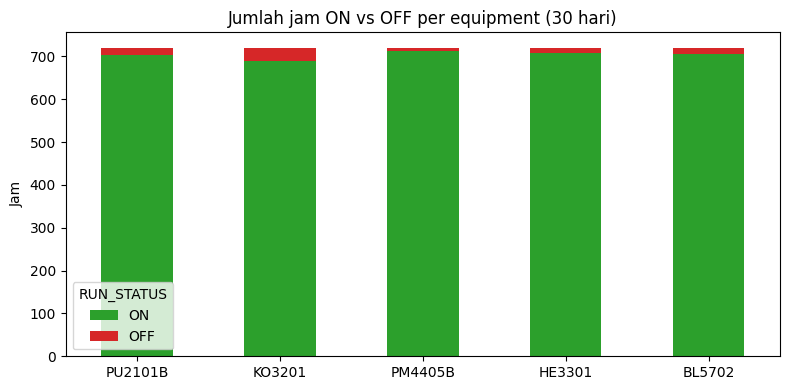

RUN_STATUS,ON,OFF
PU2101B,702,18
KO3201,688,32
PM4405B,712,8
HE3301,707,13
BL5702,706,14


In [12]:
# CELL 11 — jumlah jam OFF (downtime) per equipment
off_ct = pd.DataFrame({
    tag: df['RUN_STATUS'].value_counts()
    for tag, df in prod_history.items()
}).fillna(0).astype(int).T

off_ct.plot(kind='bar', stacked=True, figsize=(8,4),
            color={'ON':'tab:green','OFF':'tab:red'})
plt.title('Jumlah jam ON vs OFF per equipment (30 hari)')
plt.ylabel('Jam')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

off_ct

In [13]:
# CELL 12 — tren parameter proses per equipment (dropdown)
import ipywidgets as widgets

params = ['FEED', 'DISP', 'VIB', 'TEMP', 'AMP', 'PLANT_RATE']

def plot_prod(tag):
    df = prod_history[tag]
    cols = [c for c in params if c in df.columns]

    fig, axes = plt.subplots(len(cols), 1, figsize=(10, 2.5*len(cols)), sharex=True)
    if len(cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        ax.plot(df['Timestamp'], df[col], lw=0.6, color='steelblue')
        off = df[df['RUN_STATUS'] == 'OFF']
        ax.scatter(off['Timestamp'], off[col], color='red', s=10, zorder=3, label='OFF')
        ax.set_ylabel(col, fontsize=8)
        ax.legend(fontsize=7, loc='upper left')

    fig.suptitle(f"{tag} — data proses per jam (30 hari)", fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()

widgets.interact(plot_prod,
                 tag=widgets.Dropdown(options=list(prod_history.keys()), description='Equipment:'));

interactive(children=(Dropdown(description='Equipment:', options=('PU2101B', 'KO3201', 'PM4405B', 'HE3301', 'B…

In [14]:
# CELL 13 — Kesimpulan Production Data
print("="*60)
print("KESIMPULAN — PRODUCTION DATA (Sensor Otomatis Per Jam)")
print("="*60)

for tag, df in prod_history.items():
    off_hours = (df['RUN_STATUS'] == 'OFF').sum()
    total_hours = len(df)
    print(f"\n{tag}:")
    print(f"  - Downtime tercatat sensor: {off_hours} jam dari {total_hours} jam ({off_hours/total_hours*100:.1f}%)")

paling_sering_off = {tag: (df['RUN_STATUS']=='OFF').sum() for tag, df in prod_history.items()}
tag_paling_sering_off = max(paling_sering_off, key=paling_sering_off.get)
print(f"\n>> Equipment dengan downtime tercatat terbanyak: {tag_paling_sering_off} ({paling_sering_off[tag_paling_sering_off]} jam)")

KESIMPULAN — PRODUCTION DATA (Sensor Otomatis Per Jam)

PU2101B:
  - Downtime tercatat sensor: 18 jam dari 720 jam (2.5%)

KO3201:
  - Downtime tercatat sensor: 32 jam dari 720 jam (4.4%)

PM4405B:
  - Downtime tercatat sensor: 8 jam dari 720 jam (1.1%)

HE3301:
  - Downtime tercatat sensor: 13 jam dari 720 jam (1.8%)

BL5702:
  - Downtime tercatat sensor: 14 jam dari 720 jam (1.9%)

>> Equipment dengan downtime tercatat terbanyak: KO3201 (32 jam)


## Case 2 RCA

In [15]:
# CELL 14 — baca file RCA .pptx dari folder
import glob

rca_folder = "/content/drive/MyDrive/Supporting Data/Case 2: Intelligence Manufacturing/RCA - Downtime Data"
print("Folder ketemu di:", rca_folder)
rca_file_list = sorted(glob.glob(f"{rca_folder}/*.pptx"))
print("File yang kebaca:", rca_file_list)

Folder ketemu di: /content/drive/MyDrive/Supporting Data/Case 2: Intelligence Manufacturing/RCA - Downtime Data
File yang kebaca: ['/content/drive/MyDrive/Supporting Data/Case 2: Intelligence Manufacturing/RCA - Downtime Data/RCA1 - PU-2101B Mechanical Seal Leakage.pptx', '/content/drive/MyDrive/Supporting Data/Case 2: Intelligence Manufacturing/RCA - Downtime Data/RCA2 - KO-3201 High Radial Vibration Trip.pptx', '/content/drive/MyDrive/Supporting Data/Case 2: Intelligence Manufacturing/RCA - Downtime Data/RCA3 - PM-4405B Motor Bearing Failure.pptx', '/content/drive/MyDrive/Supporting Data/Case 2: Intelligence Manufacturing/RCA - Downtime Data/RCA4 - HE-3301 High Fouling — Duty Loss & High dP.pptx', '/content/drive/MyDrive/Supporting Data/Case 2: Intelligence Manufacturing/RCA - Downtime Data/RCA5 - BL-5702 High Vibration.pptx']


In [16]:
# CELL 15 — install & ekstrak SUMMARY terstruktur (bukan raw dump)
try:
    from pptx import Presentation
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "python-pptx", "-q"])
    from pptx import Presentation

import re

def extract_slides(f):
    prs = Presentation(f)
    slides_text = []
    for slide in prs.slides:
        texts = []
        for shape in slide.shapes:
            if shape.has_text_frame:
                t = shape.text_frame.text.strip()
                if t:
                    texts.append(t)
            if shape.has_table:
                for row in shape.table.rows:
                    texts.append(' | '.join(c.text.strip() for c in row.cells))
        slides_text.append('\n'.join(texts))
    return slides_text

rows = []
for f in rca_file_list:
    st = extract_slides(f)
    s1, s2, s11 = st[0], st[1], st[10]   # slide 1=header, 2=problem, 11=closure summary

    tag_plant = re.search(r'TAG / PLANT\n(.+)', s1)
    ar_no     = re.search(r'AR NUMBER\n(.+)', s1)
    date_occ  = re.search(r'DATE OCCURRENCE\n(.+)', s1)
    severity  = re.search(r'SEVERITY\n(.+)', s2)
    problem   = re.search(r'PROBLEM STATEMENT\n(.+?)\nRCA & CAPA', s2, re.S)
    downtime  = re.search(r'DOWNTIME\n([\d.]+)\s*h', s11)
    prod_loss = re.search(r'PRODUCTION LOSS\n([\d.]+)\s*ton', s11)
    est_loss  = re.search(r'ESTIMATED LOSS\n\$([\d.]+)k', s11)
    pre_risk  = re.search(r'PRE-RISK\n(\S+)\s*\((\d+)\)', s11)
    root_cause= re.search(r'ROOT CAUSE\n(.+?)\nKEY CORRECTIVE', s11, re.S)
    actions   = re.search(r'KEY CORRECTIVE / PRO-ACTIVE ACTIONS\n(.+?)\nAR-', s11, re.S)
    title_lines = s1.split('\n')

    rows.append({
        'Equipment Tag': tag_plant.group(1).split('|')[0].strip() if tag_plant else None,
        'Plant': tag_plant.group(1).split('|')[1].strip() if tag_plant else None,
        'Equipment Name': title_lines[1] if len(title_lines) > 1 else None,
        'Failure Mode': title_lines[2] if len(title_lines) > 2 else None,
        'AR Number': ar_no.group(1).strip() if ar_no else None,
        'Date Occurrence': date_occ.group(1).strip() if date_occ else None,
        'Severity': severity.group(1).strip() if severity else None,
        'Pre-Risk Level': pre_risk.group(1) if pre_risk else None,
        'Pre-Risk Score': int(pre_risk.group(2)) if pre_risk else None,
        'Downtime (h)': float(downtime.group(1)) if downtime else None,
        'Production Loss (ton)': float(prod_loss.group(1)) if prod_loss else None,
        'Estimated Loss (k USD)': float(est_loss.group(1)) if est_loss else None,
        'Problem Statement': problem.group(1).strip() if problem else None,
        'Root Cause': root_cause.group(1).strip() if root_cause else None,
        'Corrective Actions': [a.strip() for a in actions.group(1).split('•') if a.strip()] if actions else None,
    })

rca_summary = pd.DataFrame(rows).set_index('Equipment Tag')
rca_summary[['Plant','Failure Mode','Severity','Downtime (h)','Production Loss (ton)','Estimated Loss (k USD)']]

,Plant,Failure Mode,Severity,Downtime (h),Production Loss (ton),Estimated Loss (k USD)
Equipment Tag,,,,,,
PU-2101B,ARP,Mechanical Seal Leakage,Major,18.5,251.6,226.44
KO-3201,ZCU,Cracked Gas Compressor KO-3201,Catastrophic,32.0,1760.0,1584.00
PM-4405B,NUP,Cooling Water Pump PM-4405B (Motor Driven),Moderate,8.0,160.0,112.00
HE-3301,ZCU,Feed/Effluent Heat Exchanger HE-3301,Moderate,12.0,216.0,183.60
BL-5702,OPP,Product Blower BL-5702,Major,14.0,532.0,478.80


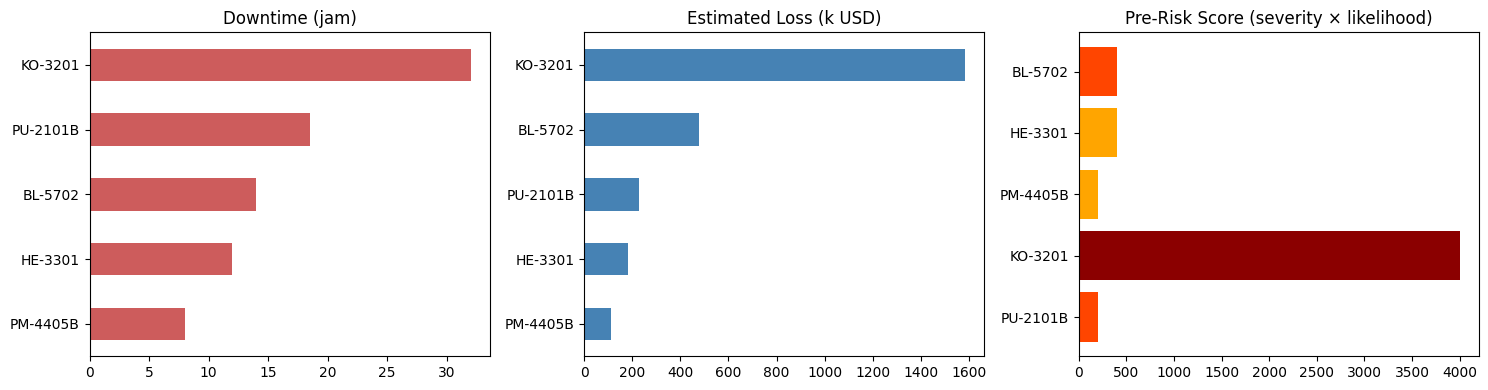

In [17]:
# CELL 16 — perbandingan ke-5 RCA (chart)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rca_summary['Downtime (h)'].sort_values().plot(kind='barh', ax=axes[0], color='indianred')
axes[0].set_title('Downtime (jam)')

rca_summary['Estimated Loss (k USD)'].sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Estimated Loss (k USD)')

sev_colors = {'Catastrophic':'darkred','Major':'orangered','Moderate':'orange','Minor':'gold'}
colors = [sev_colors.get(s, 'gray') for s in rca_summary['Severity']]
axes[2].barh(rca_summary.index, rca_summary['Pre-Risk Score'], color=colors)
axes[2].set_title('Pre-Risk Score (severity × likelihood)')

for ax in axes:
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [18]:
# CELL 17 — "kartu" penjelasan tiap RCA
from IPython.display import display, Markdown

for tag, row in rca_summary.iterrows():
    md_text = f"""### 🔧 {tag} — {row['Equipment Name']}
**Plant:** {row['Plant']}  |  **AR:** {row['AR Number']}  |  **Tanggal:** {row['Date Occurrence']}  |  **Severity:** {row['Severity']}  |  **Pre-Risk:** {row['Pre-Risk Level']} ({row['Pre-Risk Score']})  |  **Downtime:** {row['Downtime (h)']} h  |  **Loss:** ${row['Estimated Loss (k USD)']}k

**Masalah:** {row['Problem Statement']}

**Root Cause:** {row['Root Cause']}

**Key corrective & preventive actions:**
"""
    acts = row['Corrective Actions'] if isinstance(row['Corrective Actions'], list) else []
    for a in acts:
        md_text += f"- {a}\n"
    display(Markdown(md_text))
    print("—" * 80)

### 🔧 PU-2101B — Feed Charge Pump PU-2101B
**Plant:** ARP  |  **AR:** AR-2026-ARP-0117  |  **Tanggal:** 12 Mar 2026  |  **Severity:** Major  |  **Pre-Risk:** III (200)  |  **Downtime:** 18.5 h  |  **Loss:** $226.44k

**Masalah:** Mechanical seal of Feed Charge Pump PU-2101B failed on 12-Mar-2026, causing seal leakage and an unplanned feed reduction to the ARP reactor section.

**Root Cause:** Premature mechanical seal failure caused by intermittent dry-running: suction cavitation during feed swings reduced NPSH and seal-flush flow dropped below the 6 L/min minimum, with no interlock to protect the seal.

**Key corrective & preventive actions:**
- Install seal-flush flow switch with DCS alarm on PU-2101B
- Add low-NPSH / loss-of-flush trip interlock in DCS
- Revise feed-swing SOP to cap ramp at 1 T/H per minute


————————————————————————————————————————————————————————————————————————————————


### 🔧 KO-3201 — Equipment Related Risk
**Plant:** ZCU  |  **AR:** AR-2026-ZCU-0142  |  **Tanggal:** 29 Apr 2026  |  **Severity:** Catastrophic  |  **Pre-Risk:** II (4000)  |  **Downtime:** 32.0 h  |  **Loss:** $1584.0k

**Masalah:** Cracked Gas Compressor KO-3201 tripped on high-high radial vibration on 29-Apr-2026 due to journal-bearing babbitt distress driven by water-contaminated lube oil.

**Root Cause:** Journal-bearing babbitt distress caused by degraded oil-film strength from water ingress via a leaking lube-oil cooler tube, undetected due to absence of online water-in-oil monitoring, leading to rising vibration and a high-high trip.

**Key corrective & preventive actions:**
- Repair leaking lube-oil cooler tube (plug + re-test)
- Install online water-in-oil sensor on KO-3201 lube system
- Tighten KO-3201 vibration alert to 45 micron & shorten trend-review cadence


————————————————————————————————————————————————————————————————————————————————


### 🔧 PM-4405B — Equipment Related Risk
**Plant:** NUP  |  **AR:** AR-2026-NUP-0089  |  **Tanggal:** 08 Jul 2026  |  **Severity:** Moderate  |  **Pre-Risk:** III (200)  |  **Downtime:** 8.0 h  |  **Loss:** $112.0k

**Masalah:** Cooling Water Pump PM-4405B motor tripped on 08-Jul-2026 due to drive-end bearing failure from grease degradation and an over-extended re-lubrication interval.

**Root Cause:** Motor drive-end bearing failure caused by grease degradation from an over-extended, non-risk-based re-lubrication interval, undetected due to absence of bearing-temperature trending, resulting in bearing overheating and motor trip.

**Key corrective & preventive actions:**
- Revise PM-4405B re-lubrication interval to risk-based (4-monthly)
- Add motor bearing temperature trending & alert to CMMS
- Add PM-4405B/C to monthly vibration & thermography route


————————————————————————————————————————————————————————————————————————————————


### 🔧 HE-3301 — Equipment Related Risk
**Plant:** ZCU  |  **AR:** AR-2026-ZCU-0165  |  **Tanggal:** 21 May 2026  |  **Severity:** Moderate  |  **Pre-Risk:** III (400)  |  **Downtime:** 12.0 h  |  **Loss:** $183.6k

**Masalah:** Feed/Effluent Heat Exchanger HE-3301 suffered accelerated tube-side fouling reducing duty and raising dP, forcing an unplanned isolation, cleaning and partial rate cut on 21-May-2026.

**Root Cause:** Accelerated tube-side coke/polymer fouling driven by higher-than-design feed heavy-ends, allowed to progress by the absence of a dP-based cleaning trigger and fouling KPI, causing duty loss, high dP and a forced rate cut.

**Key corrective & preventive actions:**
- Add dP-based cleaning trigger & alarm for HE-3301
- Tighten feed heavy-ends control & filtration
- Add fouling factor & duty KPI to reliability dashboard


————————————————————————————————————————————————————————————————————————————————


### 🔧 BL-5702 — Equipment Related Risk
**Plant:** OPP  |  **AR:** AR-2026-OPP-0203  |  **Tanggal:** 17 Jun 2026  |  **Severity:** Major  |  **Pre-Risk:** III (400)  |  **Downtime:** 14.0 h  |  **Loss:** $478.8k

**Masalah:** Product Blower BL-5702 tripped on high vibration on 17-Jun-2026 due to coupling misalignment and a worn coupling element, halting the OPP powder-handling section.

**Root Cause:** High vibration from coupling misalignment aggravated by soft-foot and an over-aged elastomer coupling element, undetected because periodic alignment/soft-foot checks were absent from the PM and the vibration route interval was too long.

**Key corrective & preventive actions:**
- Add periodic laser alignment & soft-foot check to BL-5702 PM
- Track coupling element life & replace at 12 months
- Shorten BL-5702 vibration route to weekly


————————————————————————————————————————————————————————————————————————————————


In [19]:
# KODE 2 — ekspor root cause & aksi untuk Looker (rca_actions.csv)
rca_export = rca_summary.reset_index()
rca_export = rca_export.rename(columns={rca_export.columns[0]: 'Equipment Tag'})   # kolom pertama = tag
wanted = ['Equipment Tag', 'Plant', 'AR Number', 'Failure Mode', 'Severity',
          'Downtime (h)', 'Estimated Loss (k USD)', 'Root Cause', 'Corrective Actions']
print('Kolom yang tidak ada:', [c for c in wanted if c not in rca_export.columns])
rca_export = rca_export[[c for c in wanted if c in rca_export.columns]].copy()
rca_export['Corrective Actions'] = rca_export['Corrective Actions'].apply(
    lambda a: ' | '.join(a) if isinstance(a, list) else a)
rca_export = rca_export.rename(columns={'Corrective Actions': 'Key corrective and preventive actions'})
rca_export.to_csv('rca_actions.csv', index=False)
rca_export

Kolom yang tidak ada: []


,Equipment Tag,Plant,AR Number,Failure Mode,Severity,Downtime (h),Estimated Loss (k USD),Root Cause,Key corrective and preventive actions
0,PU-2101B,ARP,AR-2026-ARP-0117,Mechanical Seal Leakage,Major,18.5,226.44,Premature mechanical seal failure caused by in...,Install seal-flush flow switch with DCS alarm ...
1,KO-3201,ZCU,AR-2026-ZCU-0142,Cracked Gas Compressor KO-3201,Catastrophic,32.0,1584.00,Journal-bearing babbitt distress caused by deg...,Repair leaking lube-oil cooler tube (plug + re...
2,PM-4405B,NUP,AR-2026-NUP-0089,Cooling Water Pump PM-4405B (Motor Driven),Moderate,8.0,112.00,Motor drive-end bearing failure caused by grea...,Revise PM-4405B re-lubrication interval to ris...
3,HE-3301,ZCU,AR-2026-ZCU-0165,Feed/Effluent Heat Exchanger HE-3301,Moderate,12.0,183.60,Accelerated tube-side coke/polymer fouling dri...,Add dP-based cleaning trigger & alarm for HE-3...
4,BL-5702,OPP,AR-2026-OPP-0203,Product Blower BL-5702,Major,14.0,478.80,High vibration from coupling misalignment aggr...,Add periodic laser alignment & soft-foot check...


In [20]:
# KODE 3 — ekspor Preventive Action per RCA (rca_preventive.csv; harus 10 baris)
import re, os, glob
from pptx import Presentation

def preventive_from_rca(path):
    prs = Presentation(path)
    for s in prs.slides:
        texts = [sh.text_frame.text.strip() for sh in s.shapes
                 if sh.has_text_frame and sh.text_frame.text.strip()]
        if 'Preventive & Risk Analysis' not in texts or 'Preventive Action' not in texts:
            continue
        start = texts.index('Preventive Action')
        stop = next((i for i, t in enumerate(texts) if t.startswith('RISK ANALYSIS')), len(texts))
        seg = [t for t in texts[start + 1:stop] if t not in ('Plan Date', 'PIC')]
        return [seg[i:i + 5] for i in range(0, len(seg) - 4, 5)]   # item, cause, action, date, PIC
    return []

prev_rows = []
for f in rca_file_list:
    m = re.search(r'RCA\d - ([A-Z]{2}-\d{4}[A-Z]?)', os.path.basename(f))
    tag = m.group(1) if m else os.path.basename(f)
    for item, cause, action, date, pic in preventive_from_rca(f):
        prev_rows.append({'Equipment Tag': tag, 'Item': item, 'Possible root cause': cause,
                          'Preventive action': action, 'Plan date': date, 'PIC': pic})
prev_df = pd.DataFrame(prev_rows)
prev_df.to_csv('rca_preventive.csv', index=False)
print(len(prev_df), 'baris (harus 10)')
prev_df

10 baris (harus 10)


,Equipment Tag,Item,Possible root cause,Preventive action,Plan date,PIC
0,PU-2101B,P2,Suction cavitation,Revise feed-swing SOP to cap ramp at 1 T/H per...,24-Apr-2026,ROT-01
1,PU-2101B,X3,Flush system not in PM,Add seal-flush system (Plan 11) to PU-2101B PM...,24-Apr-2026,REL-05
2,KO-3201,X3,Vibration limits too wide,Tighten KO-3201 vibration alert to 45 micron &...,30-May-2026,REL-05
3,KO-3201,X2,Cooler integrity not trended,Add lube-oil cooler dP & conductivity trend to...,30-Jun-2026,REL-02
4,PM-4405B,X3,Motor not on vibration route,Add PM-4405B/C to monthly vibration & thermogr...,31-Jul-2026,REL-02
5,PM-4405B,P1,Bearing over-temp,Verify motor cooling-fan & louvre condition ea...,31-Jul-2026,ELE-01
6,HE-3301,X3,No fouling KPI,Add fouling factor & duty KPI to reliability d...,22-Jun-2026,STA-02
7,HE-3301,X2,Filter not trended,Add upstream filter dP trend & replacement tri...,30-Jun-2026,ROT-01
8,BL-5702,X3,Route interval too long,Shorten BL-5702 vibration route to weekly,18-Jul-2026,REL-05
9,BL-5702,P4,Soft-foot,Correct soft-foot & re-shim baseplate BL-5702,18-Jun-2026,ROT-01


## Case 2 Incident

In [21]:
# CELL 18 — pakai file dari folder
inc_folder = "/content/drive/MyDrive/Supporting Data/Case 2: Intelligence Manufacturing/Incident Database"
inc_file = os.path.join(inc_folder, "Incident Database.xlsx")
print("Pakai file:", inc_file)

Pakai file: /content/drive/MyDrive/Supporting Data/Case 2: Intelligence Manufacturing/Incident Database/Incident Database.xlsx


In [22]:
# CELL 19 — parsing (skip 2 baris judul, header di baris ke-3)
wb = openpyxl.load_workbook(inc_file, data_only=True)
ws = wb['Incident Database']
data = list(ws.iter_rows(values_only=True))

incident_df = pd.DataFrame(data[3:], columns=data[2]).dropna(how='all')

num_cols = ['Downtime (hrs)', 'Act. Loss (k US$)', 'Pot. Loss (k US$)', 'Total Loss (k US$)', 'Risk Score']
for c in num_cols:
    incident_df[c] = pd.to_numeric(incident_df[c], errors='coerce')
incident_df['Date of Occur.'] = pd.to_datetime(incident_df['Date of Occur.'], errors='coerce')

print(f"{len(incident_df)} insiden, {incident_df['Date of Occur.'].min().date()} s/d {incident_df['Date of Occur.'].max().date()}")
incident_df.head()

380 insiden, 2024-01-04 s/d 2026-07-25


,Serial No,MTO No.,AR No.,Plant,Tag Number,Eq. Class,Date of Occur.,Risk Case Title,Highest Impact,Pre-Risk,Risk Score,PIC (RCA),Overall Status,Discipline,Eq. Type,Component,F Mechanism,Downtime (hrs),Act. Loss (k US$),Pot. Loss (k US$),Total Loss (k US$),RCA Due Date,Month - Year
0,1,MTO-2026-ARP-0031,AR-2026-ARP-0117,ARP,PU-2101B,B,2026-03-12,Feed — Mechanical Seal Leakage,Uptime Loss,III,200,REL-05,CA/PA EXECUTION,ROT,PU,Mechanical Seal,Mechanical,18.5,226.44,67.93,294.37,2026-04-26,Mar-2026
1,2,MTO-2026-ZCU-0058,AR-2026-ZCU-0142,ZCU,KO-3201,A,2026-04-29,Cracked — High Radial Vibration Trip (Bearing ...,Class A Eq. Breakdown,II,4000,REL-05,CA/PA EXECUTION,ROT,CO,Journal Bearing,High,32.0,1584.00,475.20,2059.20,2026-06-13,Apr-2026
2,3,MTO-2026-NUP-0024,AR-2026-NUP-0089,NUP,PM-4405B,B,2026-07-08,Cooling — Motor Bearing Failure (Overheating),Uptime Loss,III,200,REL-02,CA/PA EXECUTION,ELE,EM,Motor Bearing,Motor,8.0,112.00,33.60,145.60,2026-08-22,Jul-2026
3,4,MTO-2026-ZCU-0071,AR-2026-ZCU-0165,ZCU,HE-3301,B,2026-05-21,Feed/Effluent — High Fouling — Duty Loss & Hig...,Uptime Loss,III,400,STA-02,CA/PA EXECUTION,STA,HB,Tube Bundle,High,12.0,183.60,55.08,238.68,2026-07-05,May-2026
4,5,MTO-2026-OPP-0096,AR-2026-OPP-0203,OPP,BL-5702,A,2026-06-17,Product — High Vibration (Coupling Misalignment),Class A Eq. Breakdown,III,400,ROT-01,CA/PA EXECUTION,ROT,BL,Coupling,High,14.0,478.80,143.64,622.44,2026-08-01,Jun-2026


In [23]:
# CELL 20 — ringkasan angka utama
print(f"Total insiden        : {len(incident_df)}")
print(f"Total downtime       : {incident_df['Downtime (hrs)'].sum():,.1f} jam")
print(f"Total loss           : ${incident_df['Total Loss (k US$)'].sum():,.1f}k")
print(f"Rata-rata loss/insiden: ${incident_df['Total Loss (k US$)'].mean():,.1f}k")

Total insiden        : 380
Total downtime       : 2,261.1 jam
Total loss           : $67,194.4k
Rata-rata loss/insiden: $176.8k


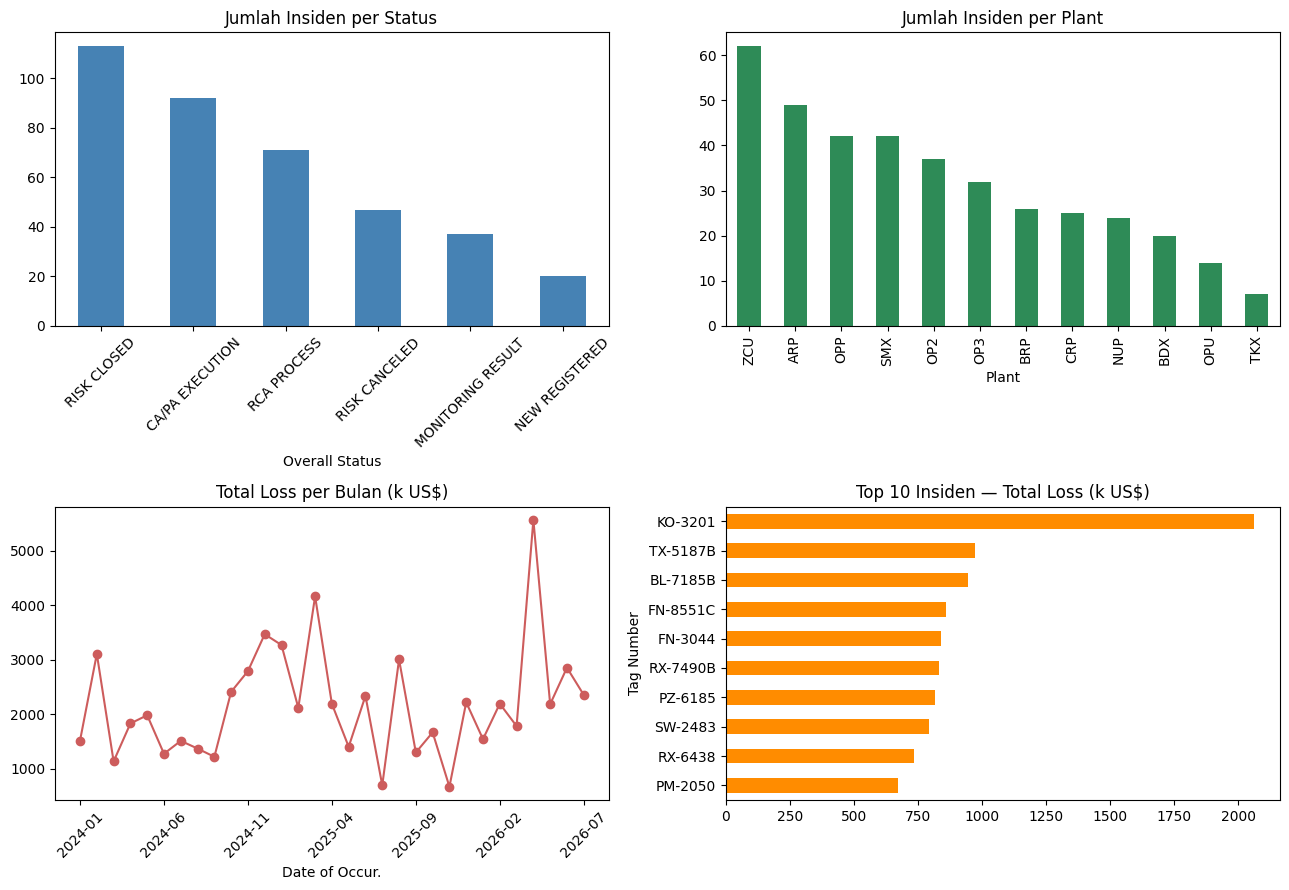

In [24]:
# CELL 21 — overview 4 panel: status, plant, tren bulanan, top loss
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

incident_df['Overall Status'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Jumlah Insiden per Status')
axes[0,0].tick_params(axis='x', rotation=45)

incident_df['Plant'].value_counts().plot(kind='bar', ax=axes[0,1], color='seagreen')
axes[0,1].set_title('Jumlah Insiden per Plant')

monthly = incident_df.groupby(incident_df['Date of Occur.'].dt.to_period('M'))['Total Loss (k US$)'].sum()
monthly.index = monthly.index.astype(str)
monthly.plot(ax=axes[1,0], color='indianred', marker='o')
axes[1,0].set_title('Total Loss per Bulan (k US$)')
axes[1,0].tick_params(axis='x', rotation=45)

top10 = incident_df.nlargest(10, 'Total Loss (k US$)').set_index('Tag Number')
top10['Total Loss (k US$)'].sort_values().plot(kind='barh', ax=axes[1,1], color='darkorange')
axes[1,1].set_title('Top 10 Insiden — Total Loss (k US$)')

plt.tight_layout()
plt.show()

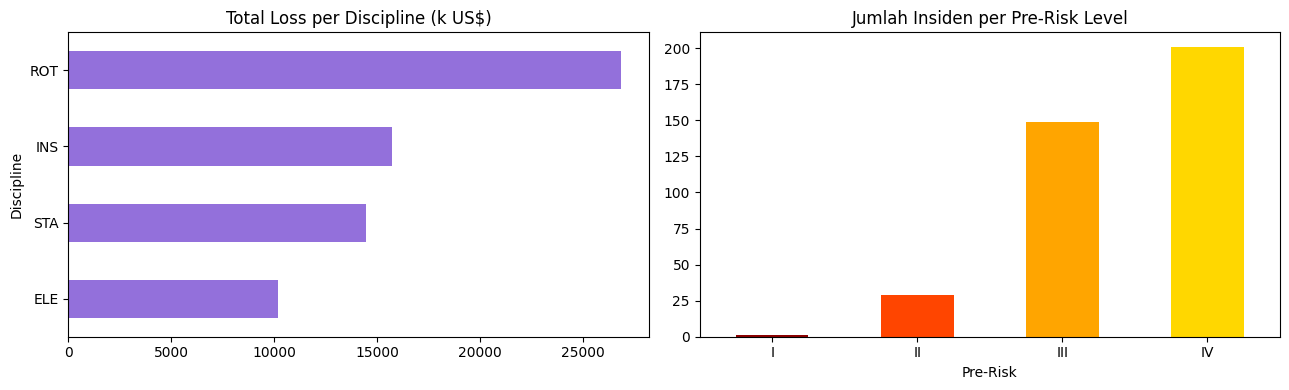

In [25]:
# CELL 22 — pola berdasarkan discipline & pre-risk
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

disc = incident_df.groupby('Discipline')['Total Loss (k US$)'].sum().sort_values()
disc.plot(kind='barh', ax=axes[0], color='mediumpurple')
axes[0].set_title('Total Loss per Discipline (k US$)')

risk_order = ['I','II','III','IV']
risk_ct = incident_df['Pre-Risk'].value_counts().reindex(risk_order).fillna(0)
risk_ct.plot(kind='bar', ax=axes[1], color=['darkred','orangered','orange','gold'])
axes[1].set_title('Jumlah Insiden per Pre-Risk Level')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

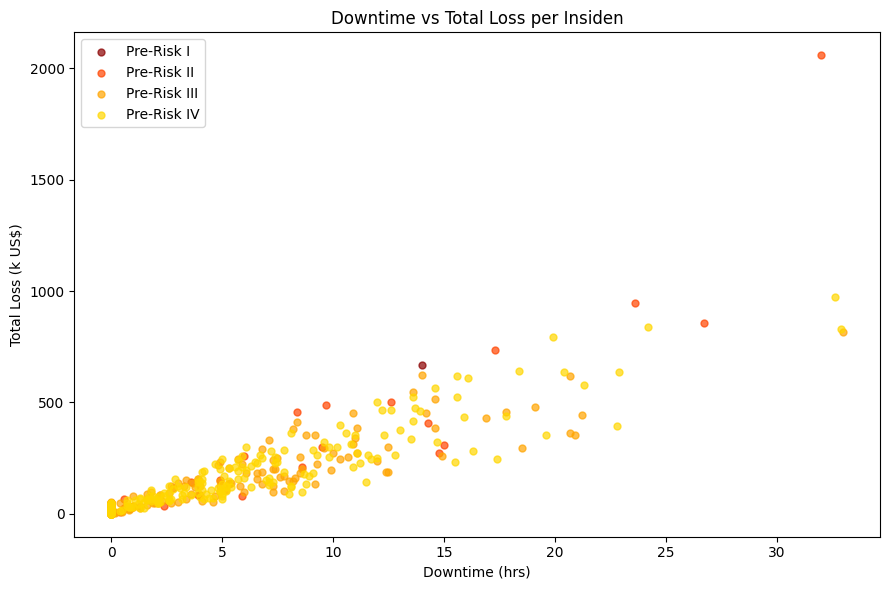

In [26]:
# CELL 23 — scatter Downtime vs Loss, warna = Pre-Risk
risk_colors = {'I':'darkred','II':'orangered','III':'orange','IV':'gold'}
fig, ax = plt.subplots(figsize=(9,6))
for risk, group in incident_df.groupby('Pre-Risk'):
    ax.scatter(group['Downtime (hrs)'], group['Total Loss (k US$)'],
               label=f'Pre-Risk {risk}', color=risk_colors.get(risk,'gray'), alpha=0.7, s=25)
ax.set_xlabel('Downtime (hrs)')
ax.set_ylabel('Total Loss (k US$)')
ax.set_title('Downtime vs Total Loss per Insiden')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# KODE C — verifikasi angka deck
# Hasil yang benar: ROT 145 | 900.0 | 26833.6 ; closure 46 128 35.9 ; Class A 38 | 9426.5 | 35.1
rot = incident_df[incident_df['Discipline'] == 'ROT']
nc = rot[rot['Overall Status'] != 'RISK CANCELED']
closed = (nc['Overall Status'] == 'RISK CLOSED').sum()
print('ROT:', len(rot), rot['Downtime (hrs)'].sum(), round(rot['Total Loss (k US$)'].sum(), 1))
print('ROT closure (closed/non-cancelled):', closed, len(nc), round(closed/len(nc)*100, 1))
a = rot[rot['Highest Impact'].str.contains('Class A', na=False)]
print('Class A:', len(a), round(a['Total Loss (k US$)'].sum(), 1),
      round(a['Total Loss (k US$)'].sum()/rot['Total Loss (k US$)'].sum()*100, 1))

ROT: 145 900.0 26833.6
ROT closure (closed/non-cancelled): 46 128 35.9
Class A: 38 9426.5 35.1


## Kapan ngecek sebelum trip (lead time dari ALARM pertama sampai TRIP)

Shortest: 6 weeks | Longest: 15 weeks | Mean: 9.6 weeks


,Equipment,First alarm date,Trip date,Lead time (weeks)
0,PU-2101B,2026-01-29,2026-03-12,6
1,PM-4405B,2026-05-27,2026-07-08,6
2,HE-3301,2026-03-12,2026-05-21,10
3,KO-3201,2026-02-11,2026-04-29,11
4,BL-5702,2026-03-04,2026-06-17,15


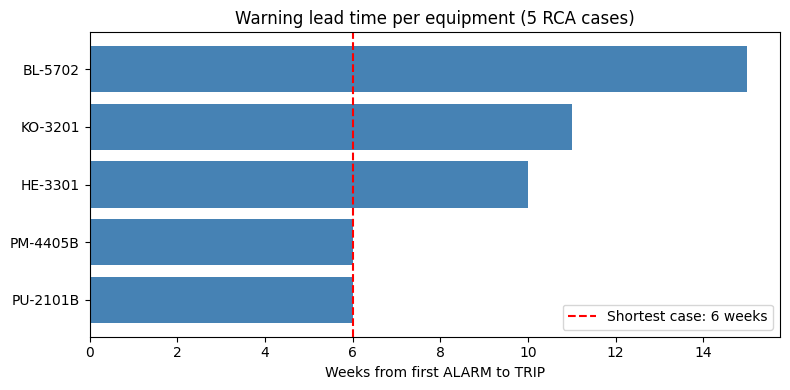

In [28]:
# KODE 1 — lead time (English). Hasil yang benar: 6, 6, 10, 11, 15 dan rata-rata 9.6 weeks
lt_rows = []
for tag, df in history_by_tag.items():
    trip = df.loc[df['Health Status'] == 'TRIP'].iloc[0]
    alarms = df.loc[df['Health Status'] == 'ALARM']
    if alarms.empty:
        continue
    first = alarms.sort_values('Week').iloc[0]
    lt_rows.append({
        'Equipment': tag,
        'First alarm date': first['Date'].date(),
        'Trip date': trip['Date'].date(),
        'Lead time (weeks)': int(trip['Week'] - first['Week']),
    })
lead_time_df = pd.DataFrame(lt_rows).sort_values('Lead time (weeks)').reset_index(drop=True)
lt = lead_time_df['Lead time (weeks)']
print(f"Shortest: {lt.min()} weeks | Longest: {lt.max()} weeks | Mean: {lt.mean():.1f} weeks")
display(lead_time_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(lead_time_df['Equipment'], lt, color='steelblue')
ax.axvline(lt.min(), color='red', ls='--', label=f'Shortest case: {lt.min()} weeks')
ax.set_xlabel('Weeks from first ALARM to TRIP')
ax.set_title('Warning lead time per equipment (5 RCA cases)')
ax.legend()
plt.tight_layout()
plt.show()
lead_time_df.to_csv('lead_time.csv', index=False)

## Gabungan Equipment Performance & Production Data (sumbu Days_to_Failure)

> Weekly equipment performance and hourly production data come from different measurement sources (confirmed by the organizer); treated as independent evidence, not aggregates.

In [29]:
# Sinkronkan Equipment Performance & Production Data ke sumbu Days_to_Failure
def norm_tag(t):
    return str(t).replace('-', '')

prod_tag_lookup = {norm_tag(t): t for t in prod_history.keys()}

def build_combined_table(tag):
    # Equipment Performance (mingguan)
    eq_cols = ['Days_to_Failure', 'Date', 'Health Status'] + params_by_tag[tag]
    eq = history_by_tag[tag][eq_cols].copy()
    eq['Days_to_Failure'] = eq['Days_to_Failure'].astype(float).round().astype(int)
    eq = eq.add_prefix('EQ_').rename(columns={'EQ_Days_to_Failure': 'Days_to_Failure'})

    # Production Data (jam-jaman -> rata-rata per hari)
    prod_tag = prod_tag_lookup.get(norm_tag(tag))
    if prod_tag is None:
        print(f"Peringatan: tidak ada data Production untuk {tag}")
        eq.insert(0, 'Equipment Tag', tag)
        return eq

    prod = prod_history[prod_tag].copy()
    prod['Days_to_Failure'] = prod['Days_to_Failure'].round().astype(int)
    num_cols = [c for c in ['FEED','DISP','VIB','TEMP','AMP','PLANT_RATE'] if c in prod.columns]
    prod_daily = prod.groupby('Days_to_Failure')[num_cols].mean().reset_index()
    prod_daily = prod_daily.add_prefix('PROD_').rename(columns={'PROD_Days_to_Failure': 'Days_to_Failure'})

    combined = pd.merge(eq, prod_daily, on='Days_to_Failure', how='outer').sort_values('Days_to_Failure')
    combined.insert(0, 'Equipment Tag', tag)
    return combined

all_combined = pd.concat([build_combined_table(tag) for tag in history_by_tag.keys()], ignore_index=True)

eq_cols_all = [c for c in all_combined.columns if c.startswith('EQ_')]
prod_cols_all = [c for c in all_combined.columns if c.startswith('PROD_')]
overlap_only = all_combined.dropna(subset=prod_cols_all, how='all').dropna(subset=eq_cols_all, how='all')

print("Total baris gabungan:", len(all_combined))
print("Baris yang tersinkron (ada di EQ dan PROD):", len(overlap_only))
overlap_only

Total baris gabungan: 262
Baris yang tersinkron (ada di EQ dan PROD): 23


,Equipment Tag,Days_to_Failure,EQ_Date,EQ_Health Status,EQ_Overall Vibration (mm/s),EQ_Seal Flush Flow (L/min),EQ_Discharge Pressure (barg),EQ_Bearing Temp (°C),PROD_FEED,PROD_DISP,PROD_VIB,PROD_TEMP,PROD_AMP,PROD_PLANT_RATE,EQ_DE Radial Vibration (micron),EQ_Lube Oil Water Content (ppm),EQ_Lube Oil Supply Press (barg),EQ_Bearing Metal Temp (°C),EQ_Motor DE Bearing Temp (°C),EQ_Motor Vibration (mm/s),EQ_Motor Ampere (A),EQ_Winding Temp (°C),EQ_Tube-side dP (bar),EQ_Heat Duty (% design),EQ_Cold Outlet Temp (°C),EQ_Feed Heavy-ends (%),EQ_2X Harmonic (mm/s),EQ_Coupling Offset (mm)
23,PU-2101B,-7,2026-03-05,ALARM,10.218,4.374,7.700,91.338,13.669217,9.471217,3.773783,64.764348,135.365217,13.876130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,PU-2101B,0,2026-03-12,TRIP,11.220,3.920,7.350,96.900,6.563160,4.245680,3.011520,52.126400,66.854800,6.651000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,PU-2101B,7,2026-03-19,NORMAL,3.624,6.231,9.554,58.931,13.597261,9.478043,3.851565,65.023478,135.148261,13.844522,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44,PU-2101B,14,2026-03-26,NORMAL,3.770,6.512,9.768,61.511,13.627480,9.505120,3.766640,65.219600,136.162800,13.818360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,KO-3201,-28,2026-04-01,ALARM,NaN,NaN,NaN,NaN,55.549900,9.505350,28.730000,65.102000,135.188000,55.929050,59.123,1062.337,1.335,98.832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76,KO-3201,-21,2026-04-08,ALARM,NaN,NaN,NaN,NaN,54.600304,9.442261,28.722565,64.800870,134.736957,56.513261,60.529,1135.420,1.313,100.992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
83,KO-3201,-14,2026-04-15,ALARM,NaN,NaN,NaN,NaN,54.771520,9.484320,28.778640,64.872800,135.926000,56.083280,66.730,1237.785,1.219,104.623,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90,KO-3201,-7,2026-04-22,ALARM,NaN,NaN,NaN,NaN,54.974130,9.502739,28.736522,64.655652,134.592609,55.840870,71.674,1372.791,1.122,107.142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,KO-3201,0,2026-04-29,TRIP,NaN,NaN,NaN,NaN,26.344280,4.720360,45.771160,52.006400,68.149600,27.322440,76.500,1530.000,1.078,112.200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,PM-4405B,-7,2026-07-01,ALARM,NaN,NaN,NaN,NaN,19.956522,9.479913,3.885739,64.975217,134.196522,20.315870,NaN,NaN,NaN,NaN,87.236,7.372,162.307,135.486,NaN,NaN,NaN,NaN,NaN,NaN


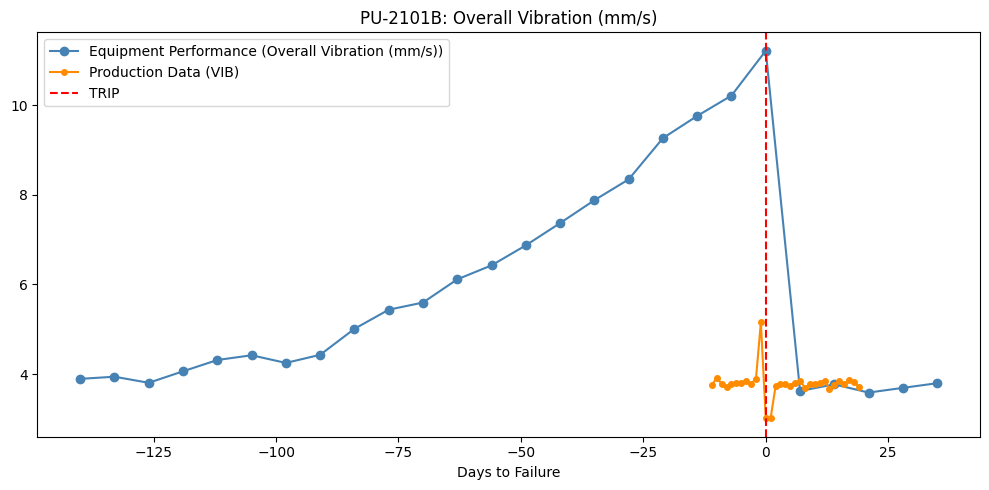

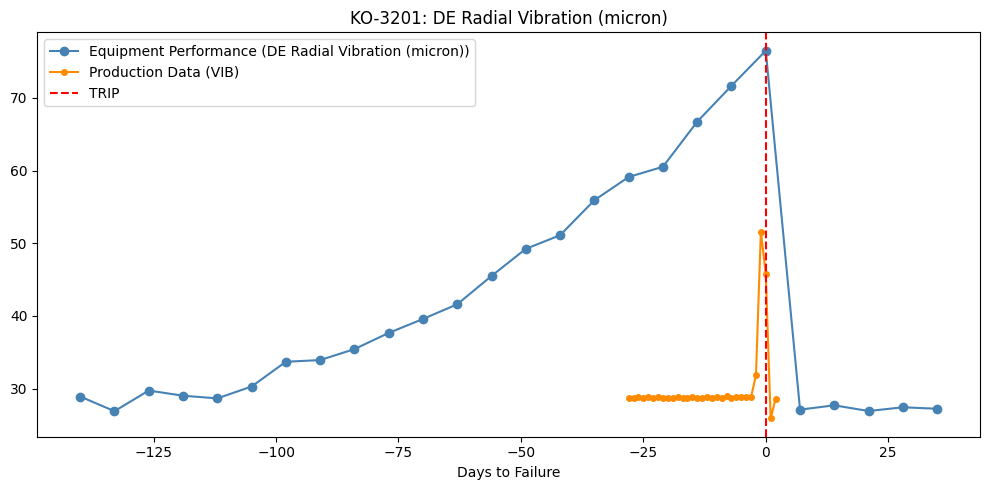

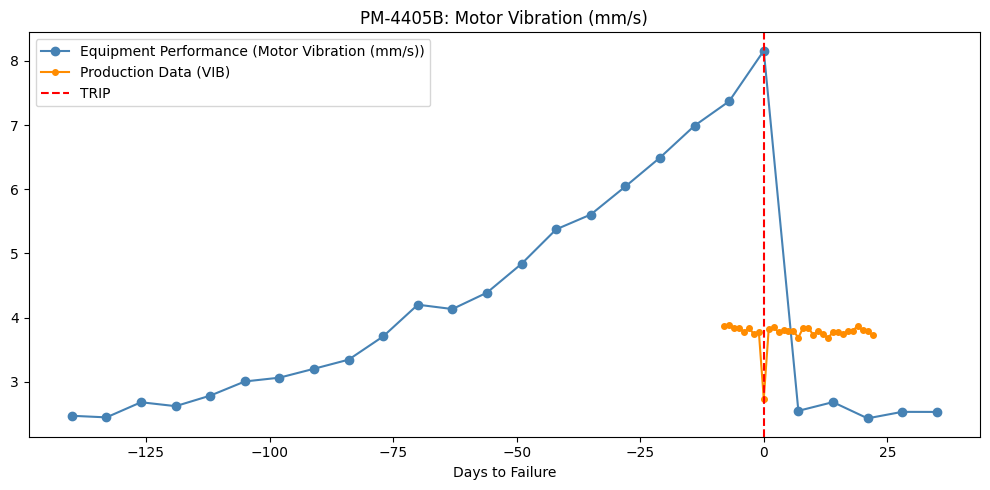

[HE-3301] Tidak ada kolom mengandung 'Vibration'. Kolom tersedia: ['Tube-side dP (bar)', 'Heat Duty (% design)', 'Cold Outlet Temp (°C)', 'Feed Heavy-ends (%)']


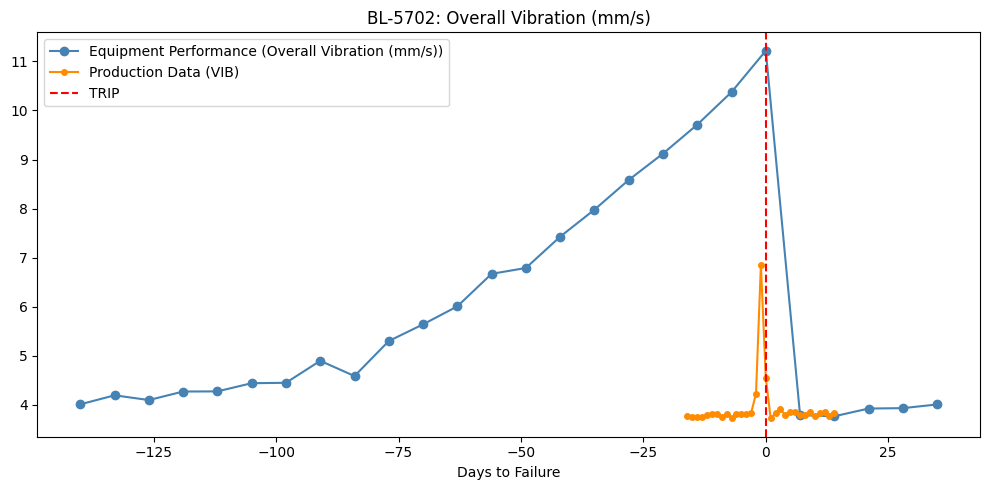

In [30]:
# plot perbandingan EQ vs PROD per equipment (auto-detect nama kolom)
def plot_eq_vs_prod_auto(tag, keyword, prod_param):
    eq = history_by_tag[tag]
    eq_param = next((c for c in params_by_tag[tag] if keyword.lower() in c.lower()), None)
    if eq_param is None:
        print(f"[{tag}] Tidak ada kolom mengandung '{keyword}'. Kolom tersedia: {params_by_tag[tag]}")
        return

    prod_tag = prod_tag_lookup.get(norm_tag(tag))
    prod = prod_history[prod_tag].copy()
    prod['Days_r'] = prod['Days_to_Failure'].round().astype(int)
    prod_daily = prod.groupby('Days_r')[prod_param].mean()

    fig, ax = plt.subplots(figsize=(10,5))
    ax.plot(eq['Days_to_Failure'], eq[eq_param], 'o-', label=f'Equipment Performance ({eq_param})', color='steelblue')
    ax.plot(prod_daily.index, prod_daily.values, 'o-', label=f'Production Data ({prod_param})', color='darkorange', markersize=4)
    ax.axvline(0, color='red', ls='--', label='TRIP')
    ax.set_xlabel('Days to Failure')
    ax.set_title(f'{tag}: {eq_param}')
    ax.legend()
    plt.tight_layout()
    plt.show()

for tag in history_by_tag:
    plot_eq_vs_prod_auto(tag, 'Vibration', 'VIB')

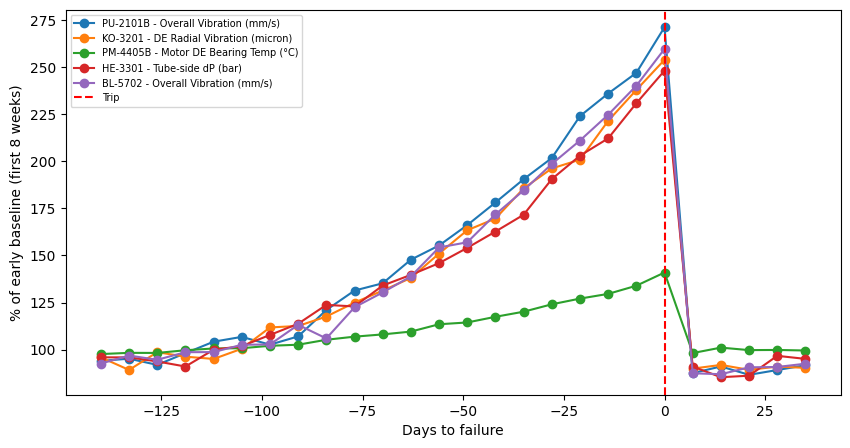

In [31]:
# KODE E — overlay semua equipment, dinormalisasi ke % baseline (8 minggu pertama)
fig, ax = plt.subplots(figsize=(10, 5))
for tag, df in history_by_tag.items():
    col = params_by_tag[tag][0]
    base = df[col].iloc[:8].mean()
    ax.plot(df['Days_to_Failure'], df[col] / base * 100, marker='o', label=f"{tag} - {col}")
ax.axvline(0, color='red', ls='--', label='Trip')
ax.set_xlabel('Days to failure'); ax.set_ylabel('% of early baseline (first 8 weeks)')
ax.legend(fontsize=7); plt.show()

## Early warning dari data Production (sensor per jam)

In [32]:
# cari kapan parameter production mulai naik di atas ambang (sudah pakai KODE A untuk baseline)
def cari_awal_kenaikan(tag, prod_param, persen_ambang=30, max_dip_toleransi=2):
    prod_tag = prod_tag_lookup.get(norm_tag(tag))
    prod = prod_history[prod_tag].copy().sort_values('Timestamp').reset_index(drop=True)

    if 'RUN_STATUS' in prod.columns:
        prod = prod[prod['RUN_STATUS'] == 'ON'].reset_index(drop=True)

    # KODE A — baseline = kondisi sehat (minimal 7 hari sebelum trip)
    baseline_data = prod[prod['Hours_to_Failure'] <= -7*24]   # minimal 7 hari sebelum trip
    if len(baseline_data) < 24:                               # kalau terlalu sedikit
        baseline_data = prod.iloc[:5*24]                      # pakai 5 hari pertama
    baseline_mean = baseline_data[prod_param].mean()
    threshold = baseline_mean * (1 + persen_ambang/100)

    sebelum_trip = prod[prod['Hours_to_Failure'] < 0].sort_values('Hours_to_Failure', ascending=False)
    jam_mulai_naik = None
    dip_count = 0
    for _, row in sebelum_trip.iterrows():
        if row[prod_param] > threshold:
            jam_mulai_naik = row['Hours_to_Failure']
            dip_count = 0
        else:
            dip_count += 1
            if dip_count > max_dip_toleransi:
                break

    nilai_maks = sebelum_trip[prod_param].max()
    gap_pct = round((nilai_maks - threshold) / threshold * 100, 1)

    return {
        'Equipment Tag': tag, 'Parameter': prod_param,
        'Baseline': round(baseline_mean, 2), 'Threshold': round(threshold, 2),
        'Jam sebelum trip': abs(round(jam_mulai_naik, 1)) if jam_mulai_naik is not None else None,
        'Nilai Maks Sblm Trip': round(nilai_maks, 2), 'Gap ke Ambang (%)': gap_pct,
    }


def sensitivity_analysis(tag, daftar_parameter, daftar_ambang=[30,25,20,15,12,10,8,5,3,2,1]):
    hasil = []
    for param in daftar_parameter:
        for pct in daftar_ambang:
            r = cari_awal_kenaikan(tag, param, persen_ambang=pct)
            r['Ambang (%)'] = pct
            hasil.append(r)
    return pd.DataFrame(hasil)


def rekomendasi_terbaik(df, ambang_minimum=10):
    kandidat = df[(df['Ambang (%)'] >= ambang_minimum) & df['Jam sebelum trip'].notna()]
    if kandidat.empty:
        return None
    return kandidat.sort_values('Jam sebelum trip', ascending=False).iloc[0]

In [33]:
prod_param_map = {'PU-2101B':'VIB', 'KO-3201':'VIB', 'PM-4405B':'VIB', 'HE-3301':'DISP', 'BL-5702':'VIB'}
param_alternatif = {'PU-2101B':['VIB','TEMP','AMP'], 'KO-3201':['VIB','TEMP','AMP'],
                    'PM-4405B':['VIB','TEMP','AMP'], 'HE-3301':['DISP','TEMP','FEED'],
                    'BL-5702':['VIB','TEMP','AMP']}

kesimpulan_final = {}
for tag, param_default in prod_param_map.items():
    hasil_default = cari_awal_kenaikan(tag, param_default, persen_ambang=30)
    if hasil_default['Jam sebelum trip'] is not None:
        kesimpulan_final[tag] = {**hasil_default, 'Sumber': 'default (30%)'}
    else:
        sens = sensitivity_analysis(tag, param_alternatif[tag])
        best = rekomendasi_terbaik(sens, ambang_minimum=10)
        if best is not None:
            kesimpulan_final[tag] = {**best.to_dict(), 'Sumber': 'parameter alternatif'}
        else:
            kesimpulan_final[tag] = {'Equipment Tag': tag, 'Sumber': 'TIDAK ADA — perlu inspeksi manual'}

In [34]:
# Fallback rate-of-change (khusus equipment yang gagal deteksi via threshold biasa)
def cari_kenaikan_cepat(tag, prod_param, window=5, persen_ambang_slope=20):
    prod_tag = prod_tag_lookup.get(norm_tag(tag))
    prod = prod_history[prod_tag].copy().sort_values('Timestamp').reset_index(drop=True)
    if 'RUN_STATUS' in prod.columns:
        prod = prod[prod['RUN_STATUS']=='ON'].reset_index(drop=True)

    prod['pct_change_roll'] = prod[prod_param].pct_change(periods=window) * 100
    sebelum_trip = prod[prod['Hours_to_Failure'] < 0].sort_values('Hours_to_Failure', ascending=False)

    lonjakan = sebelum_trip[sebelum_trip['pct_change_roll'].abs() > persen_ambang_slope]
    if lonjakan.empty:
        return {'Equipment Tag': tag, 'Parameter': prod_param, 'Jam sebelum trip': None}

    jam = lonjakan['Hours_to_Failure'].max()
    return {'Equipment Tag': tag, 'Parameter': prod_param,
            'Jam sebelum trip': abs(round(jam,1)), 'Metode': 'rate-of-change', 'Ambang Slope (%)': persen_ambang_slope}


def rekomendasi_rate_of_change(tag, daftar_parameter, daftar_slope=[30,25,20,15,12,10],
                               batas_wajar_jam=(6, 72)):
    """
    Cari parameter+slope PALING KETAT yang lolos (mulai dari 30% turun ke bawah).
    Cuma terima hasil kalau lead time-nya masuk rentang wajar (default 6-72 jam),
    biar nggak kebawa noise kayak PLANT_RATE 444 jam atau TEMP 6 jam yang
    kepepet banget sama waktu trip.
    """
    for slope in daftar_slope:
        for param in daftar_parameter:
            r = cari_kenaikan_cepat(tag, param, persen_ambang_slope=slope)
            jam = r['Jam sebelum trip']
            if jam is not None and batas_wajar_jam[0] <= jam <= batas_wajar_jam[1]:
                return r
    return None


for tag, k in kesimpulan_final.items():
    if 'TIDAK ADA' in k.get('Sumber', ''):
        param_list = param_alternatif.get(tag, [])
        fallback = rekomendasi_rate_of_change(tag, param_list)
        if fallback is not None:
            kesimpulan_final[tag] = {**fallback, 'Sumber': 'rate-of-change (fallback)'}

In [35]:
# KESIMPULAN AKHIR — EARLY WARNING PER EQUIPMENT
print("="*70)
print("KESIMPULAN AKHIR — EARLY WARNING PER EQUIPMENT")
print("="*70)

for tag, k in kesimpulan_final.items():
    print(f"\n🔧 {tag}")
    if 'TIDAK ADA' in k.get('Sumber', ''):
        print("  → Tidak ada parameter production yang cukup sensitif.")
        print("  → REKOMENDASI: andalkan inspeksi manual (Equipment Performance) sebagai leading indicator.")
    elif k.get('Metode') == 'rate-of-change':
        print(f"  → Parameter terbaik : {k['Parameter']} (deteksi via rate-of-change, ambang slope ±{k['Ambang Slope (%)']}%)")
        print(f"  → Lead time deteksi : {k['Jam sebelum trip']} jam ({round(k['Jam sebelum trip']/24,1)} hari) sebelum trip")
        interval_cek = max(round(k['Jam sebelum trip']/2), 1)
        print(f"  → REKOMENDASI: jadwalkan cek tiap ≤{interval_cek} jam (metode: laju perubahan, bukan level absolut).")
    else:
        print(f"  → Parameter terbaik : {k['Parameter']} (ambang +{k.get('Ambang (%)', 30)}%, sumber: {k['Sumber']})")
        print(f"  → Lead time deteksi : {k['Jam sebelum trip']} jam ({round(k['Jam sebelum trip']/24,1)} hari) sebelum trip")
        interval_cek = max(round(k['Jam sebelum trip']/2), 1)
        print(f"  → REKOMENDASI: jadwalkan cek tiap ≤{interval_cek} jam untuk margin aman.")

KESIMPULAN AKHIR — EARLY WARNING PER EQUIPMENT

🔧 PU-2101B
  → Parameter terbaik : VIB (ambang +30%, sumber: default (30%))
  → Lead time deteksi : 31.0 jam (1.3 hari) sebelum trip
  → REKOMENDASI: jadwalkan cek tiap ≤16 jam untuk margin aman.

🔧 KO-3201
  → Parameter terbaik : VIB (ambang +30%, sumber: default (30%))
  → Lead time deteksi : 39.0 jam (1.6 hari) sebelum trip
  → REKOMENDASI: jadwalkan cek tiap ≤20 jam untuk margin aman.

🔧 PM-4405B
  → Parameter terbaik : TEMP (ambang +10%, sumber: parameter alternatif)
  → Lead time deteksi : 27.0 jam (1.1 hari) sebelum trip
  → REKOMENDASI: jadwalkan cek tiap ≤14 jam untuk margin aman.

🔧 HE-3301
  → Tidak ada parameter production yang cukup sensitif.
  → REKOMENDASI: andalkan inspeksi manual (Equipment Performance) sebagai leading indicator.

🔧 BL-5702
  → Parameter terbaik : VIB (ambang +30%, sumber: default (30%))
  → Lead time deteksi : 43.0 jam (1.8 hari) sebelum trip
  → REKOMENDASI: jadwalkan cek tiap ≤22 jam untuk margin aman.

In [36]:
# (opsional) detail sensitivity untuk PM-4405B dan HE-3301
hasil_pm4405b = sensitivity_analysis('PM-4405B', daftar_parameter=['VIB', 'TEMP', 'AMP'])
hasil_he3301 = sensitivity_analysis('HE-3301', daftar_parameter=['DISP', 'TEMP', 'FEED'])

print("Rekomendasi PM-4405B:")
print(rekomendasi_terbaik(hasil_pm4405b))
print("\nRekomendasi HE-3301:")
print(rekomendasi_terbaik(hasil_he3301))

display(hasil_pm4405b)
display(hasil_he3301)

Rekomendasi PM-4405B:
Equipment Tag           PM-4405B
Parameter                   TEMP
Baseline                   65.11
Threshold                  71.62
Jam sebelum trip            27.0
Nilai Maks Sblm Trip       83.04
Gap ke Ambang (%)           15.9
Ambang (%)                    10
Name: 16, dtype: object

Rekomendasi HE-3301:
None


,Equipment Tag,Parameter,Baseline,Threshold,Jam sebelum trip,Nilai Maks Sblm Trip,Gap ke Ambang (%),Ambang (%)
0,PM-4405B,VIB,3.83,4.98,NaN,4.45,-10.7,30
1,PM-4405B,VIB,3.83,4.79,NaN,4.45,-7.1,25
2,PM-4405B,VIB,3.83,4.59,NaN,4.45,-3.2,20
3,PM-4405B,VIB,3.83,4.40,NaN,4.45,1.0,15
4,PM-4405B,VIB,3.83,4.29,2.0,4.45,3.7,12
5,PM-4405B,VIB,3.83,4.21,3.0,4.45,5.6,10
6,PM-4405B,VIB,3.83,4.13,3.0,4.45,7.5,8
7,PM-4405B,VIB,3.83,4.02,3.0,4.45,10.6,5
8,PM-4405B,VIB,3.83,3.94,3.0,4.45,12.7,3
9,PM-4405B,VIB,3.83,3.90,3.0,4.45,13.8,2


,Equipment Tag,Parameter,Baseline,Threshold,Jam sebelum trip,Nilai Maks Sblm Trip,Gap ke Ambang (%),Ambang (%)
0,HE-3301,DISP,9.52,12.37,NaN,10.03,-18.9,30
1,HE-3301,DISP,9.52,11.89,NaN,10.03,-15.7,25
2,HE-3301,DISP,9.52,11.42,NaN,10.03,-12.2,20
3,HE-3301,DISP,9.52,10.94,NaN,10.03,-8.4,15
4,HE-3301,DISP,9.52,10.66,NaN,10.03,-5.9,12
5,HE-3301,DISP,9.52,10.47,NaN,10.03,-4.2,10
6,HE-3301,DISP,9.52,10.28,NaN,10.03,-2.4,8
7,HE-3301,DISP,9.52,9.99,NaN,10.03,0.4,5
8,HE-3301,DISP,9.52,9.80,20.0,10.03,2.3,3
9,HE-3301,DISP,9.52,9.71,25.0,10.03,3.3,2


In [37]:
# KODE G — Jadwal Inspeksi per Equipment (pengganti "5 Equipment, 1 Line Produksi")
print("JADWAL INSPEKSI PER EQUIPMENT (interval masing-masing)")
print("=" * 60)
for tag, k in kesimpulan_final.items():
    if 'TIDAK ADA' in k.get('Sumber', ''):
        print(f"{tag}: tidak ada indikator production yang sensitif -> andalkan inspeksi mingguan (Equipment Performance)")
    else:
        jam = k['Jam sebelum trip']
        interval = max(round(jam / 2), 1)
        print(f"{tag}: peringatan ~{jam} jam sebelum trip -> cek tiap <= {interval} jam")

JADWAL INSPEKSI PER EQUIPMENT (interval masing-masing)
PU-2101B: peringatan ~31.0 jam sebelum trip -> cek tiap <= 16 jam
KO-3201: peringatan ~39.0 jam sebelum trip -> cek tiap <= 20 jam
PM-4405B: peringatan ~27.0 jam sebelum trip -> cek tiap <= 14 jam
HE-3301: tidak ada indikator production yang sensitif -> andalkan inspeksi mingguan (Equipment Performance)
BL-5702: peringatan ~43.0 jam sebelum trip -> cek tiap <= 22 jam


In [38]:
# KODE D — false-alarm rate (hasil IN-SAMPLE: ambang dibuat dari data sehat yang sama -> ini sanity check, BUKAN validasi)
def false_alarm_rate(tag, param, threshold):
    p = prod_history[prod_tag_lookup[norm_tag(tag)]]
    p = p[p['RUN_STATUS'] == 'ON']
    healthy = p[p['Hours_to_Failure'] <= -7*24]
    if healthy.empty:
        return None
    return round((healthy[param] > threshold).mean() * 100, 1)

for tag, k in kesimpulan_final.items():
    if 'Threshold' in k:
        print(tag, k['Parameter'], 'false alarm % =', false_alarm_rate(tag, k['Parameter'], k['Threshold']))

PU-2101B VIB false alarm % = 0.0
KO-3201 VIB false alarm % = 0.0
PM-4405B TEMP false alarm % = 0.0
BL-5702 VIB false alarm % = 0.0


In [39]:
# KODE H — cek angka deck setelah rerun (harus cocok semua)
# Harus: 380 | 2261.1 | 67194.4 ; lead time min 6, max 15, mean 9.6 ; PM compliance [92]
print('Incidents:', len(incident_df),
      '| Downtime h:', round(incident_df['Downtime (hrs)'].sum(), 1),
      '| Total loss k US$:', round(incident_df['Total Loss (k US$)'].sum(), 1))
print('Status:', incident_df['Overall Status'].value_counts().to_dict())
print('Lead time weeks: min', lead_time_df['Lead time (weeks)'].min(),
      'max', lead_time_df['Lead time (weeks)'].max(),
      'mean', round(lead_time_df['Lead time (weeks)'].mean(), 1))
print('PM compliance values:', sorted(kpi_df['PM Compliance (%)'].unique()))

Incidents: 380 | Downtime h: 2261.1 | Total loss k US$: 67194.4
Status: {'RISK CLOSED': 113, 'CA/PA EXECUTION': 92, 'RCA PROCESS': 71, 'RISK CANCELED': 47, 'MONITORING RESULT': 37, 'NEW REGISTERED': 20}
Lead time weeks: min 6 max 15 mean 9.6
PM compliance values: [np.int64(92)]


In [40]:
# KODE F — (opsional) similar-incident retrieval (TF-IDF); hanya pakai kolom yang benar-benar ada
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

incident_df = incident_df.reset_index(drop=True)
text_cols = [c for c in ['Risk Case Title', 'Eq. Type', 'Component', 'F Mechanism'] if c in incident_df.columns]
print('Kolom teks yang dipakai:', text_cols)
docs = incident_df[text_cols].fillna('').astype(str).agg(' '.join, axis=1)
vec = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
X = vec.fit_transform(docs)

def similar_incidents(tag, k=3):
    i = incident_df.index[incident_df['Tag Number'] == tag][0]
    s = cosine_similarity(X[i], X).ravel()
    s[i] = -1
    top = s.argsort()[::-1][:k]
    show_cols = ['Tag Number'] + [c for c in ['Risk Case Title', 'F Mechanism'] if c in incident_df.columns] \
                + ['Total Loss (k US$)', 'Overall Status']
    out = incident_df.loc[top, show_cols].copy()
    out['Similarity'] = s[top].round(2)
    return out

similar_incidents('PU-2101B')

Kolom teks yang dipakai: ['Risk Case Title', 'Eq. Type', 'Component', 'F Mechanism']


,Tag Number,Risk Case Title,F Mechanism,Total Loss (k US$),Overall Status,Similarity
291,PU-4574B,PU-4574B Mechanical Seal Leak,Leakage,123.89,RISK CLOSED,0.61
99,KO-1172C,KO-1172C Mechanical Seal Leak,Leakage,24.35,RISK CANCELED,0.52
347,KO-1744,KO-1744 Mechanical Seal Leak,Leakage,107.30,RISK CLOSED,0.52


## Early-warning summary (English, untuk video dan deck)

In [41]:
print("Production-sensor early warning per equipment")
print("-" * 60)
for tag, k in kesimpulan_final.items():
    if 'TIDAK ADA' in k.get('Sumber', ''):
        print(f"{tag}: no sensitive production indicator -> rely on weekly equipment inspection")
    else:
        print(f"{tag}: {k['Parameter']} flagged ~{k['Jam sebelum trip']} h before trip ({k['Sumber']})")
print()
print("Weekly-inspection warning (first ALARM to TRIP):")
print(lead_time_df.to_string(index=False))

Production-sensor early warning per equipment
------------------------------------------------------------
PU-2101B: VIB flagged ~31.0 h before trip (default (30%))
KO-3201: VIB flagged ~39.0 h before trip (default (30%))
PM-4405B: TEMP flagged ~27.0 h before trip (parameter alternatif)
HE-3301: no sensitive production indicator -> rely on weekly equipment inspection
BL-5702: VIB flagged ~43.0 h before trip (default (30%))

Weekly-inspection warning (first ALARM to TRIP):
Equipment First alarm date  Trip date  Lead time (weeks)
 PU-2101B       2026-01-29 2026-03-12                  6
 PM-4405B       2026-05-27 2026-07-08                  6
  HE-3301       2026-03-12 2026-05-21                 10
  KO-3201       2026-02-11 2026-04-29                 11
  BL-5702       2026-03-04 2026-06-17                 15
